# Updated: Occlusion Mapping on Synthetic Images with Custom CNN

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob


## Load Custom CNN Model

In [5]:
model = keras.models.load_model(
"/content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/melanoma_cnn_arch1_150epochs_64batch.keras"
)
IMG_SIZE = (224,224)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Synthetic Images

In [12]:
def load_images(folder, max_images=100):
    paths = glob(os.path.join(folder, "*.jpg"))[:max_images]
    images_list = []
    for p in paths:
        img = tf.keras.preprocessing.image.load_img(p, target_size=IMG_SIZE)
        img = tf.keras.preprocessing.image.img_to_array(img)/255.0
        images_list.append(img)
    return np.array(images_list), paths # Return both images and their paths

loaded_images, all_image_paths = load_images( # Store both
"/content/drive/MyDrive/MSAI/SEIS766_VAI/FinalProject/data/images_syn",
max_images=100
)
images = loaded_images # Keep `images` variable name for consistency with later cells

## Filter by Confidence Threshold

In [13]:
CONF_THRESHOLD = 0.8  # adjust if needed

preds = model.predict(images, verbose=0).flatten()

selected_mask = (preds >= CONF_THRESHOLD) # Create a boolean mask for filtering
selected_images = images[selected_mask]
selected_image_paths = np.array(all_image_paths)[selected_mask] # Filter paths using the same mask

print("Selected:", len(selected_images))

Selected: 100


## Occlusion Function

In [8]:
def occlusion_map(model, image, patch_size=30, stride=20):
    h, w, _ = image.shape
    heatmap = np.zeros((h, w))
    baseline = model.predict(image[np.newaxis,...], verbose=0)[0][0]

    for y in range(0, h, stride):
        for x in range(0, w, stride):
            occluded = image.copy()
            occluded[y:y+patch_size, x:x+patch_size,:] = 0.5
            pred = model.predict(occluded[np.newaxis,...], verbose=0)[0][0]
            heatmap[y:y+patch_size, x:x+patch_size] += (baseline - pred)

    return heatmap


## Generate Occlusion Maps

In [10]:
from tqdm.notebook import tqdm

maps = []
for img in tqdm(selected_images,desc="Generating occlusion maps"):
    maps.append(occlusion_map(model, img))

maps = np.array(maps)


Generating occlusion maps:   0%|          | 0/100 [00:00<?, ?it/s]

## Visualization

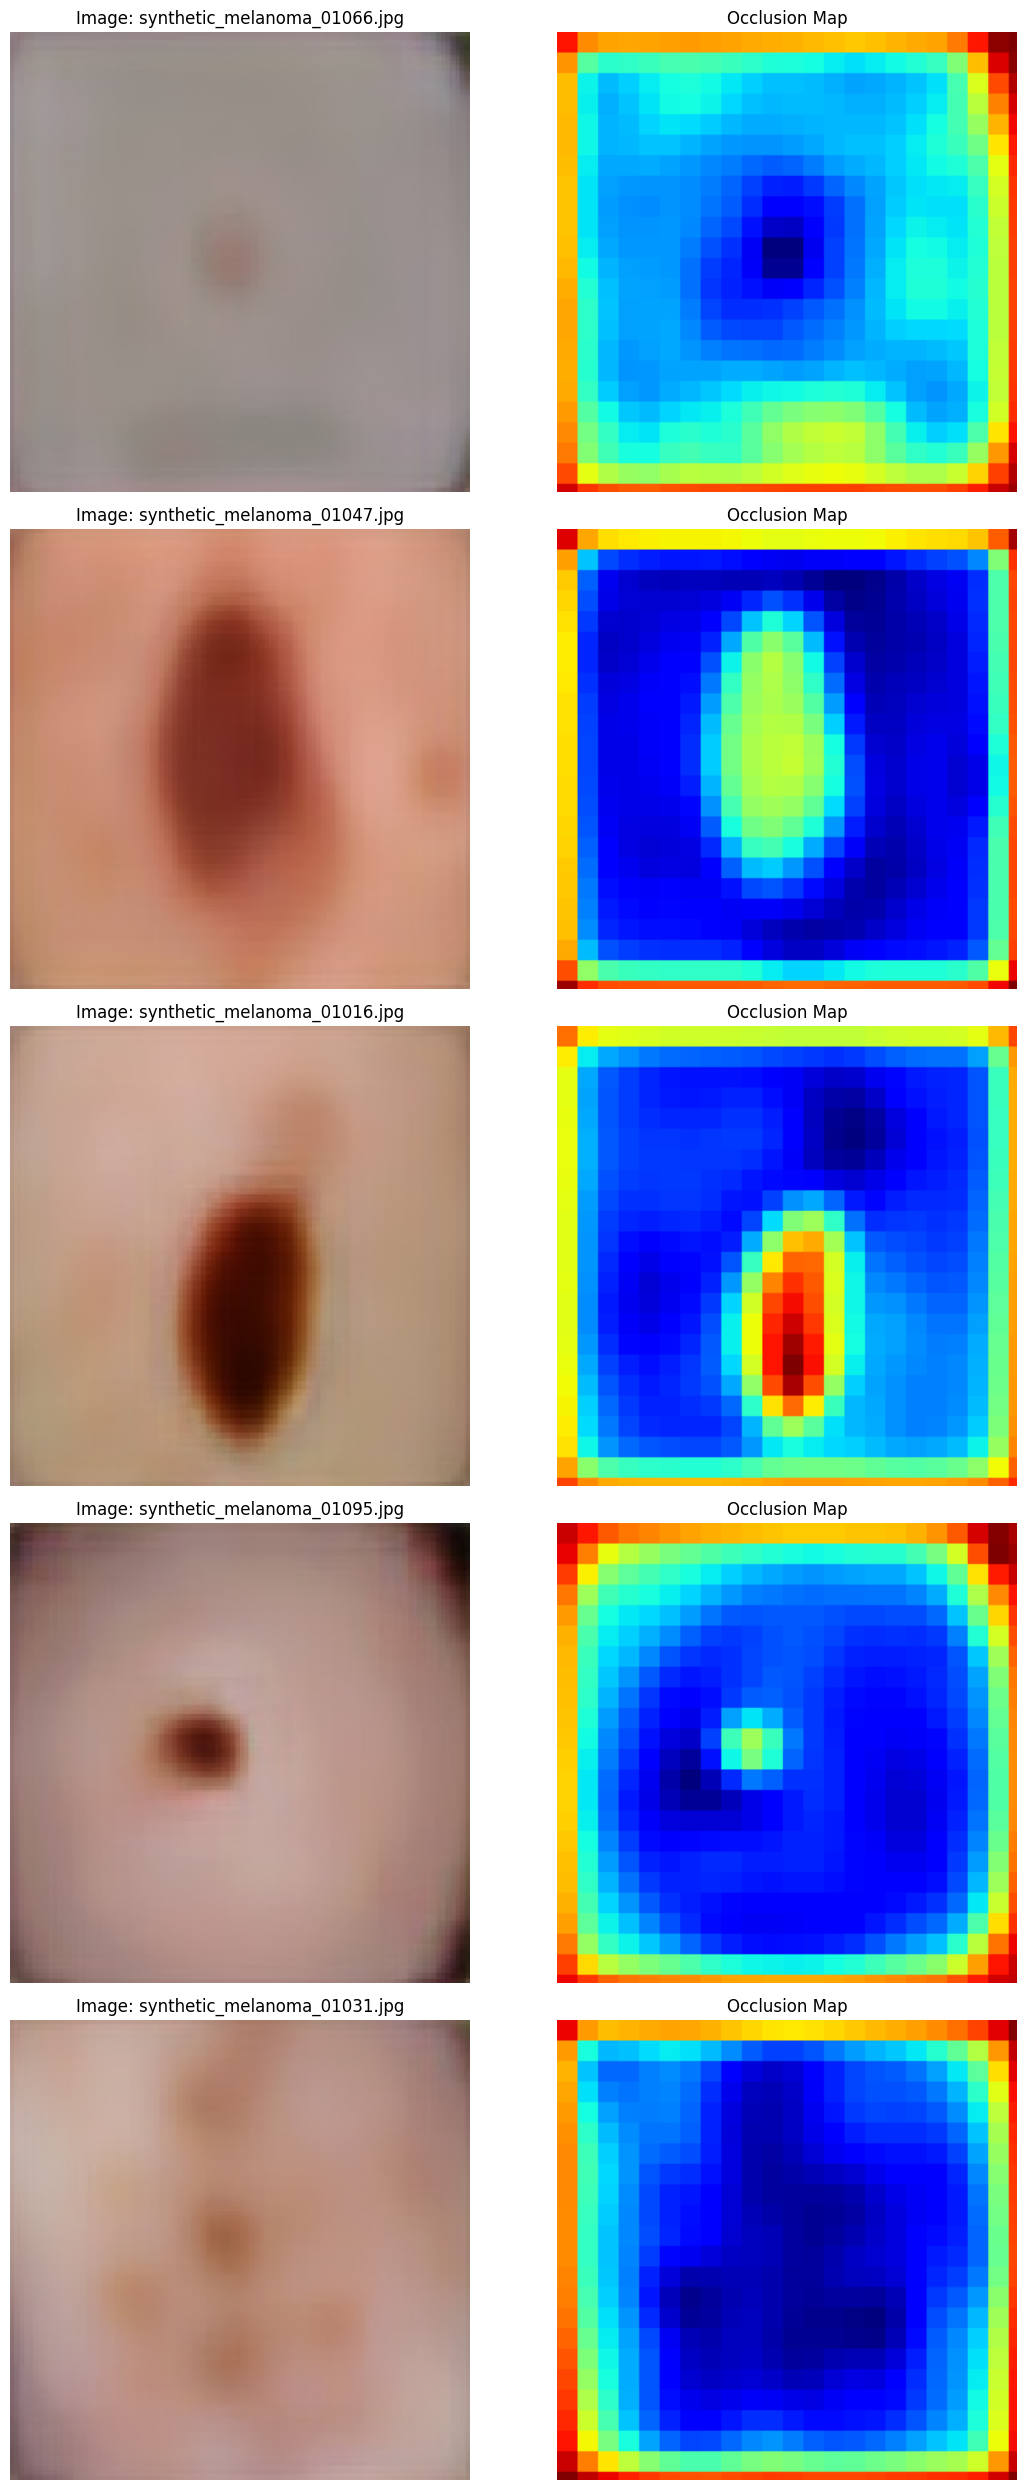

In [14]:
import matplotlib.pyplot as plt
import os # Need os.path.basename to extract filename

def display_occlusion_examples(num_examples=5):
    # Adjust figure size dynamically for multiple rows of plots
    fig = plt.figure(figsize=(12, num_examples * 5))
    for i in range(num_examples):
        if i >= len(selected_images):
            print(f"Only {len(selected_images)} examples available. Displaying all.")
            break

        # Display Image
        plt.subplot(num_examples, 2, i*2 + 1)
        plt.imshow(selected_images[i])
        # Extract filename from the full path
        filename = os.path.basename(selected_image_paths[i])
        plt.title(f"Image: {filename}")
        plt.axis('off')

        # Display Occlusion Map
        plt.subplot(num_examples, 2, i*2 + 2)
        plt.imshow(maps[i], cmap='jet')
        plt.title("Occlusion Map")
        plt.axis('off')
    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

display_occlusion_examples(5) # Call the new function to display 5 examples